In [2]:
# # Download KING

# %cd ~
# !wget https://www.kingrelatedness.com/Linux-king.tar.gz
# !tar -xzf Linux-king.tar.gz
# !chmod +x king
# %cd ~/cse284-relative-finding

In [3]:
# Run LWK analysis
!chmod +x LWK_Analysis.sh
!./LWK_Analysis.sh

=== Step 1: Check data dimensions ===
Samples (.fam):
97 /home/r3james/public/ps2/ibd/ps2_ibd.lwk.fam
Variants (.bim):
911045 /home/r3james/public/ps2/ibd/ps2_ibd.lwk.bim

=== Step 2: Run PLINK --genome (IBD) on LWK data ===
Timing PLINK...
PLINK v1.90b6.9 64-bit (4 Mar 2019)            www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /home/r3james/cse284-relative-finding/results/lwk.ibd.log.
Options in effect:
  --bfile /home/r3james/public/ps2/ibd/ps2_ibd.lwk
  --genome
  --min 0.1
  --out /home/r3james/cse284-relative-finding/results/lwk.ibd

257783 MB RAM detected; reserving 128891 MB for main workspace.
911045 variants loaded from .bim file.
97 people (0 males, 0 females, 97 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
/home/r3james/cse284-relative-finding/results/lwk.ibd.nosex .
Using up to 127 threads (change this with --threads).
Before main variant filters, 97 founders and 0 nonfounders prese

In [4]:
import pandas as pd, sys, os

genome_file = os.path.expanduser("~/cse284-relative-finding/results/lwk.ibd.genome")
if not os.path.exists(genome_file):
    print("PLINK genome file not found — skipping summary.")
    sys.exit(0)

df = pd.read_csv(genome_file, delim_whitespace=True)

# First-degree relatives: PI_HAT > 0.45
first_deg = df[df['PI_HAT'] > 0.45]

# Parent-child: Z1 ≈ 1, Z2 ≈ 0
parent_child = first_deg[first_deg['Z2'] < 0.05]
print("=== Putative Parent-Child Pairs ===")
print(parent_child[['IID1','IID2','Z0','Z1','Z2','PI_HAT']].to_string(index=False))

# Siblings: Z2 > 0.15
siblings = first_deg[first_deg['Z2'] > 0.15]
print("\n=== Putative Sibling Pairs ===")
print(siblings[['IID1','IID2','Z0','Z1','Z2','PI_HAT']].to_string(index=False))

print(f"\nTotal first-degree pairs found: {len(first_deg)}")
print(f"  Parent-child: {len(parent_child)}")
print(f"  Siblings:     {len(siblings)}")

=== Putative Parent-Child Pairs ===
   IID1    IID2     Z0     Z1     Z2  PI_HAT
NA19313 NA19331 0.0049 0.9545 0.0406  0.5179
NA19381 NA19382 0.0042 0.9605 0.0353  0.5156
NA19445 NA19453 0.0029 0.9523 0.0447  0.5209
NA19469 NA19470 0.0041 0.9589 0.0370  0.5165

=== Putative Sibling Pairs ===
   IID1    IID2     Z0     Z1     Z2  PI_HAT
NA19331 NA19334 0.2875 0.4486 0.2638  0.4881
NA19347 NA19352 0.2087 0.5012 0.2901  0.5407
NA19373 NA19374 0.2321 0.4664 0.3015  0.5347
NA19396 NA19397 0.2240 0.5032 0.2728  0.5244
NA19434 NA19444 0.2625 0.4900 0.2475  0.4925
NA19443 NA19470 0.2406 0.4773 0.2821  0.5207

Total first-degree pairs found: 10
  Parent-child: 4
  Siblings:     6


In [5]:
#!/usr/bin/env python3
"""
CSE284 Final Project: PLINK vs KING for Relative Finding
LWK dataset (ps2_ibd) — compare relatedness estimates from both tools.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import time
import subprocess

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

RESULTS_DIR   = os.path.expanduser("~/cse284-relative-finding/results")
LWK_BFILE     = os.path.expanduser("~/public/ps2/ibd/ps2_ibd.lwk")
KING_BIN      = os.path.expanduser("~/king")

plink_filepath = os.path.join(RESULTS_DIR, "lwk.ibd.genome")
# KING --related found no close relatives, so we use the --ibdseg summary file
king_filepath  = os.path.join(RESULTS_DIR, "lwk_king_ibdseg.seg")

os.makedirs("figures", exist_ok=True)



In [6]:

# ============================================================
# 1. LOAD DATA
# ============================================================
# --- Population metadata ---
# All samples in ps2_ibd.lwk are LWK (Luhya, Kenya).
# Build a simple ID→Population map directly from the .fam file.
fam_df = pd.read_csv(LWK_BFILE + ".fam", sep=r'\s+', header=None,
                     names=["FID", "IID", "PAT", "MAT", "SEX", "PHENO"])
pop_map = {iid: "LWK" for iid in fam_df["IID"]}
print(f"Samples loaded from .fam: {len(pop_map)}")

# --- PLINK .genome output ---
plink_df = pd.read_csv(plink_filepath, sep=r'\s+')
plink_df["pair"] = plink_df.apply(
    lambda r: tuple(sorted([r["IID1"], r["IID2"]])), axis=1
)
plink_df["Pop1"] = plink_df["IID1"].map(pop_map)
plink_df["Pop2"] = plink_df["IID2"].map(pop_map)
plink_df["SamePop"] = plink_df["Pop1"] == plink_df["Pop2"]  # always True here
print(f"PLINK: {len(plink_df)} pairs loaded (PI_HAT >= 0.1 filter applied)")

# --- KING --ibdseg .seg output ---
# Columns: FID1 ID1 FID2 ID2 IBD1Seg IBD2Seg PropIBD InfType
king_df = pd.read_csv(king_filepath, sep='\t')
king_df["pair"] = king_df.apply(
    lambda r: tuple(sorted([r["ID1"], r["ID2"]])), axis=1
)
king_df["Pop1"] = king_df["ID1"].map(pop_map)
king_df["Pop2"] = king_df["ID2"].map(pop_map)
king_df["SamePop"] = king_df["Pop1"] == king_df["Pop2"]
print(f"KING:  {len(king_df)} pairs loaded from --ibdseg")
print(f"       InfType breakdown:\n{king_df['InfType'].value_counts().to_string()}")



Samples loaded from .fam: 97
PLINK: 35 pairs loaded (PI_HAT >= 0.1 filter applied)
KING:  617 pairs loaded from --ibdseg
       InfType breakdown:
UN     571
4th     23
3rd      8
FS       6
2nd      5
PO       4


In [7]:

# ============================================================
# 2. CLASSIFY RELATIONSHIPS
# ============================================================
def classify_plink(row):
    """Classify relationship from PLINK Z0, Z1, Z2 values."""
    z0, z1, z2, pi_hat = row["Z0"], row["Z1"], row["Z2"], row["PI_HAT"]
    if pi_hat > 0.9:
        return "MZ Twin/Duplicate"
    elif z1 > 0.9:
        return "Parent-Child"
    elif 0.4 < z1 < 0.6 and z0 < 0.3:
        return "Full Sibling"
    elif z2 < 0.1 and 0.4 < z1 < 0.6:
        return "2nd Degree"
    elif z2 < 0.1 and 0.15 < z1 < 0.35:
        return "3rd Degree"
    elif pi_hat > 0.4:
        return "1st Degree (other)"
    elif pi_hat > 0.15:
        return "Possibly Related"
    else:
        return "Unrelated"

def classify_king_ibdseg(row):
    """
    Classify from KING --ibdseg PropIBD and IBD segment proportions.
    KING's InfType is already inferred; we also compute a kinship proxy:
        Kinship ≈ IBD2Seg/2 + IBD1Seg/4
    for comparison with PLINK PI_HAT (≈ 2 * kinship).
    """
    ibd1, ibd2 = row["IBD1Seg"], row["IBD2Seg"]
    kinship_proxy = ibd2 / 2 + ibd1 / 4
    inf_type = row["InfType"]
    if inf_type in ("Dup/MZ",):
        return "MZ Twin/Duplicate"
    elif inf_type == "PO":
        return "Parent-Child"
    elif inf_type == "FS":
        return "Full Sibling"
    elif inf_type in ("2nd",):
        return "2nd Degree"
    elif inf_type in ("3rd",):
        return "3rd Degree"
    elif kinship_proxy > 0.0442:
        return "Possibly Related"
    else:
        return "Unrelated / Background"

# Add a kinship proxy to king_df for plotting
king_df["Kinship_proxy"] = king_df["IBD2Seg"] / 2 + king_df["IBD1Seg"] / 4
king_df["Relationship_KING"] = king_df.apply(classify_king_ibdseg, axis=1)

plink_df["Relationship_PLINK"] = plink_df.apply(classify_plink, axis=1)

print("\n=== PLINK Relationship Classification ===")
print(plink_df["Relationship_PLINK"].value_counts())
print("\n=== KING --ibdseg Relationship Classification ===")
print(king_df["Relationship_KING"].value_counts())




=== PLINK Relationship Classification ===
Unrelated           11
3rd Degree           9
Full Sibling         6
Parent-Child         4
2nd Degree           4
Possibly Related     1
Name: Relationship_PLINK, dtype: int64

=== KING --ibdseg Relationship Classification ===
Unrelated / Background    594
3rd Degree                  8
Full Sibling                6
2nd Degree                  5
Parent-Child                4
Name: Relationship_KING, dtype: int64


In [8]:

# ============================================================
# 3. COMPARE: MERGE PLINK AND KING RESULTS
# ============================================================
plink_related = plink_df[plink_df["Relationship_PLINK"] != "Unrelated"].copy()
king_related  = king_df.copy()   # ibdseg already filters to pairs with IBD signal

merged = pd.merge(
    plink_related[["pair", "IID1", "IID2", "Z0", "Z1", "Z2", "PI_HAT",
                   "Relationship_PLINK", "Pop1", "Pop2"]],
    king_related[["pair", "ID1", "ID2", "IBD1Seg", "IBD2Seg",
                  "PropIBD", "Kinship_proxy", "InfType", "Relationship_KING"]],
    on="pair",
    how="outer",
    indicator=True
)

print("\n=== Overlap Analysis ===")
print(f"Pairs found by PLINK only:  {(merged['_merge'] == 'left_only').sum()}")
print(f"Pairs found by KING only:   {(merged['_merge'] == 'right_only').sum()}")
print(f"Pairs found by both:        {(merged['_merge'] == 'both').sum()}")

both = merged[merged["_merge"] == "both"].copy()
if len(both) > 0:
    print(f"\n=== Agreement on shared pairs ({len(both)}) ===")
    print("\nTop related pairs (by KING PropIBD):")
    top = both.sort_values("PropIBD", ascending=False).head(20)
    print(top[["IID1", "IID2", "Z0", "Z1", "Z2", "PI_HAT",
               "PropIBD", "InfType",
               "Relationship_PLINK", "Relationship_KING"]].to_string(index=False))



=== Overlap Analysis ===
Pairs found by PLINK only:  0
Pairs found by KING only:   593
Pairs found by both:        24

=== Agreement on shared pairs (24) ===

Top related pairs (by KING PropIBD):
   IID1    IID2     Z0     Z1     Z2  PI_HAT  PropIBD InfType Relationship_PLINK Relationship_KING
NA19347 NA19352 0.2087 0.5012 0.2901  0.5407   0.5353      FS       Full Sibling      Full Sibling
NA19373 NA19374 0.2321 0.4664 0.3015  0.5347   0.5160      FS       Full Sibling      Full Sibling
NA19443 NA19470 0.2406 0.4773 0.2821  0.5207   0.5025      FS       Full Sibling      Full Sibling
NA19445 NA19453 0.0029 0.9523 0.0447  0.5209   0.5000      PO       Parent-Child      Parent-Child
NA19313 NA19331 0.0049 0.9545 0.0406  0.5179   0.4998      PO       Parent-Child      Parent-Child
NA19469 NA19470 0.0041 0.9589 0.0370  0.5165   0.4997      PO       Parent-Child      Parent-Child
NA19381 NA19382 0.0042 0.9605 0.0353  0.5156   0.4990      PO       Parent-Child      Parent-Child
NA19396 NA1

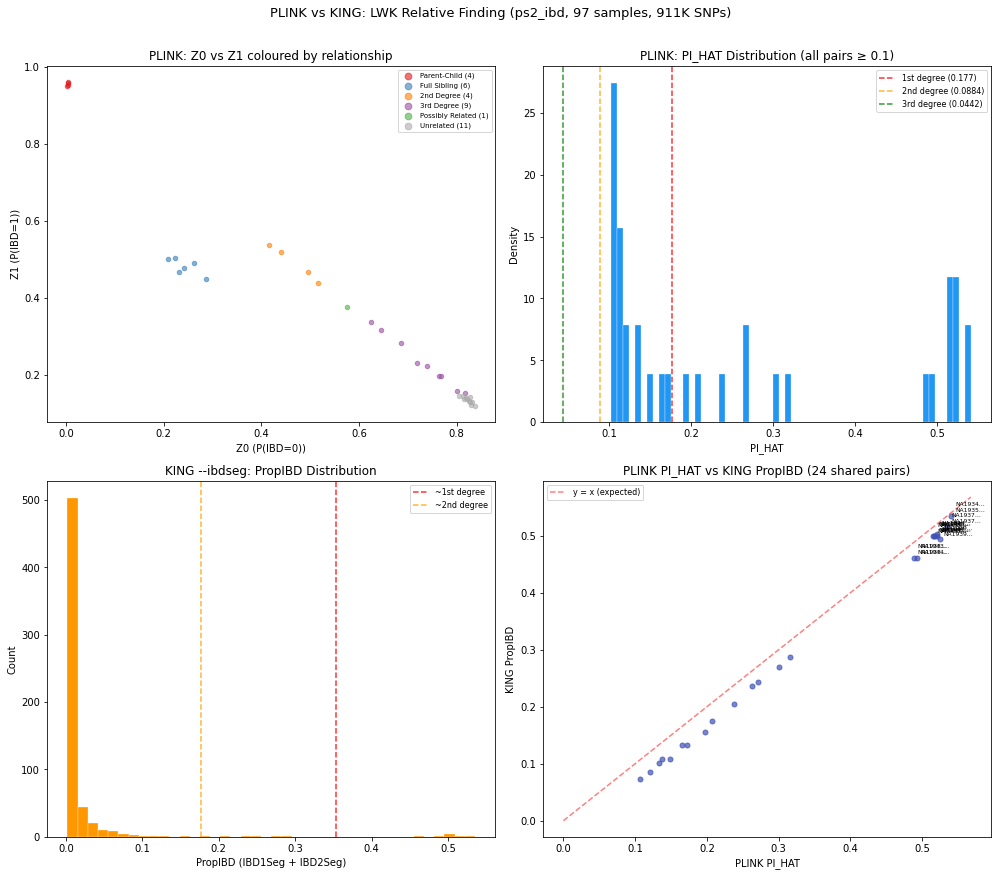

Saved: figures/plink_vs_king_lwk.png


In [9]:
# ============================================================
# 4. VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Plot 1: PLINK Z1 vs Z0 — colour by relationship class ---
ax = axes[0, 0]
rel_colors = {
    "Parent-Child":       "#e41a1c",
    "Full Sibling":       "#377eb8",
    "2nd Degree":         "#ff7f00",
    "3rd Degree":         "#984ea3",
    "1st Degree (other)": "#a65628",
    "Possibly Related":   "#4daf4a",
    "Unrelated":          "#aaaaaa",
}
for rel, color in rel_colors.items():
    mask = plink_df["Relationship_PLINK"] == rel
    if mask.sum() == 0:
        continue
    ax.scatter(plink_df.loc[mask, "Z0"], plink_df.loc[mask, "Z1"],
               alpha=0.6, s=20, c=[color], label=f"{rel} ({mask.sum()})")
ax.set_xlabel("Z0 (P(IBD=0))")
ax.set_ylabel("Z1 (P(IBD=1))")
ax.set_title("PLINK: Z0 vs Z1 coloured by relationship")
ax.legend(fontsize=7, markerscale=1.5)

# --- Plot 2: PLINK PI_HAT distribution ---
ax = axes[0, 1]
ax.hist(plink_df["PI_HAT"], bins=60, color="#2196F3", edgecolor="white",
        linewidth=0.3, density=True)
for thresh, label, color in [
    (0.177, "1st degree (0.177)", "red"),
    (0.0884, "2nd degree (0.0884)", "orange"),
    (0.0442, "3rd degree (0.0442)", "green"),
]:
    ax.axvline(thresh, color=color, linestyle="--", alpha=0.8, label=label)
ax.set_xlabel("PI_HAT")
ax.set_ylabel("Density")
ax.set_title("PLINK: PI_HAT Distribution (all pairs ≥ 0.1)")
ax.legend(fontsize=8)

# --- Plot 3: KING PropIBD distribution ---
ax = axes[1, 0]
if len(king_df) > 0:
    ax.hist(king_df["PropIBD"], bins=40, color="#FF9800", edgecolor="white",
            linewidth=0.3)
    for thresh, label, color in [
        (0.177 * 2, "~1st degree", "red"),
        (0.0884 * 2, "~2nd degree", "orange"),
    ]:
        ax.axvline(thresh, color=color, linestyle="--", alpha=0.8, label=label)
    ax.set_xlabel("PropIBD (IBD1Seg + IBD2Seg)")
    ax.set_ylabel("Count")
    ax.set_title("KING --ibdseg: PropIBD Distribution")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No KING pairs", ha="center", va="center",
            transform=ax.transAxes)

# --- Plot 4: PLINK PI_HAT vs KING PropIBD for overlapping pairs ---
ax = axes[1, 1]
if len(both) > 0:
    sc = ax.scatter(both["PI_HAT"], both["PropIBD"], alpha=0.7, s=25,
                    c="#3f51b5")
    # Theoretical: PropIBD ≈ PI_HAT (both are ~2*kinship)
    lim = max(both["PI_HAT"].max(), both["PropIBD"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", alpha=0.5, label="y = x (expected)")
    ax.set_xlabel("PLINK PI_HAT")
    ax.set_ylabel("KING PropIBD")
    ax.set_title(f"PLINK PI_HAT vs KING PropIBD ({len(both)} shared pairs)")
    ax.legend(fontsize=8)
    # Annotate close-relative pairs
    for _, row in both[both["PI_HAT"] > 0.4].iterrows():
        ax.annotate(f"{row['IID1'][:6]}…\n{row['IID2'][:6]}…",
                    (row["PI_HAT"], row["PropIBD"]),
                    fontsize=6, xytext=(4, 4), textcoords="offset points")
else:
    ax.text(0.5, 0.5, "No overlapping pairs", ha="center", va="center",
            transform=ax.transAxes)

plt.suptitle("PLINK vs KING: LWK Relative Finding (ps2_ibd, 97 samples, 911K SNPs)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/plink_vs_king_lwk.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/plink_vs_king_lwk.png")




=== Population Structure Note ===
All 97 samples are LWK — a single, closely-related African population.
Expected effect: elevated background PropIBD / PI_HAT relative to
European or admixed panels, making 3rd-degree detection noisier.

PLINK 'related' pairs by PI_HAT threshold:
  PI_HAT > 0.4500  (1st degree  ):   10 pairs
  PI_HAT > 0.1770  (2nd degree  ):   17 pairs
  PI_HAT > 0.0884  (3rd degree  ):   35 pairs
  PI_HAT > 0.0442  (4th degree  ):   35 pairs

KING InfType breakdown:
UN     571
4th     23
3rd      8
FS       6
2nd      5
PO       4

=== Summary: Detected Relationships ===
                        PLINK  KING
2nd Degree                  4     5
3rd Degree                  9     8
Full Sibling                6     6
Parent-Child                4     4
Possibly Related            1     0
Unrelated                  11     0
Unrelated / Background      0   594

=== Runtime Benchmarking (LWK data, 97 samples, 911K SNPs) ===
PLINK --genome: 1.68 seconds
KING --related: 9.82 s

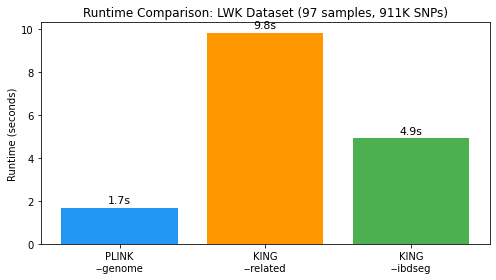

Saved: figures/runtime_comparison_lwk.png

=== Analysis Complete ===


In [10]:

# ============================================================
# 5. POPULATION STRUCTURE NOTE
# ============================================================
print("\n=== Population Structure Note ===")
print("All 97 samples are LWK — a single, closely-related African population.")
print("Expected effect: elevated background PropIBD / PI_HAT relative to")
print("European or admixed panels, making 3rd-degree detection noisier.")
print("\nPLINK 'related' pairs by PI_HAT threshold:")
for thresh, label in [(0.45, "1st degree"), (0.177, "2nd degree"),
                       (0.0884, "3rd degree"), (0.0442, "4th degree")]:
    n = (plink_df["PI_HAT"] > thresh).sum()
    print(f"  PI_HAT > {thresh:.4f}  ({label:12s}): {n:4d} pairs")

print("\nKING InfType breakdown:")
print(king_df["InfType"].value_counts().to_string())


# ============================================================
# 6. SUMMARY TABLE
# ============================================================
print("\n=== Summary: Detected Relationships ===")
summary = pd.DataFrame({
    "PLINK": plink_df["Relationship_PLINK"].value_counts(),
    "KING":  king_df["Relationship_KING"].value_counts()
}).fillna(0).astype(int)
print(summary)


# ============================================================
# 7. RUNTIME BENCHMARKING (LWK dataset)
# ============================================================
print("\n=== Runtime Benchmarking (LWK data, 97 samples, 911K SNPs) ===")

# PLINK timing
start = time.time()
subprocess.run(
    ["plink", "--bfile", LWK_BFILE, "--genome",
     "--out", os.path.join(RESULTS_DIR, "benchmark_plink_lwk")],
    capture_output=True
)
plink_time = time.time() - start
print(f"PLINK --genome: {plink_time:.2f} seconds")

# KING --related timing
start = time.time()
subprocess.run(
    [KING_BIN, "-b", LWK_BFILE + ".bed",
     "--related", "--degree", "2",
     "--prefix", os.path.join(RESULTS_DIR, "benchmark_king_related_lwk")],
    capture_output=True
)
king_related_time = time.time() - start
print(f"KING --related: {king_related_time:.2f} seconds")

# KING --ibdseg timing
start = time.time()
subprocess.run(
    [KING_BIN, "-b", LWK_BFILE + ".bed",
     "--ibdseg",
     "--prefix", os.path.join(RESULTS_DIR, "benchmark_king_ibdseg_lwk")],
    capture_output=True
)
king_ibdseg_time = time.time() - start
print(f"KING --ibdseg:  {king_ibdseg_time:.2f} seconds")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["PLINK\n--genome", "KING\n--related", "KING\n--ibdseg"]
times  = [plink_time, king_related_time, king_ibdseg_time]
colors = ["#2196F3", "#FF9800", "#4CAF50"]
bars = ax.bar(labels, times, color=colors)
ax.set_ylabel("Runtime (seconds)")
ax.set_title("Runtime Comparison: LWK Dataset (97 samples, 911K SNPs)")
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{t:.1f}s", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("figures/runtime_comparison_lwk.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/runtime_comparison_lwk.png")

print("\n=== Analysis Complete ===")

In [11]:
"""
CSE284 Final Project: Validate PLINK and KING against PED ground truth.
LWK dataset (ps2_ibd, 97 samples).

Ground truth is extracted from the 1000 Genomes PED file,
filtered to only the individuals present in ps2_ibd.lwk.fam.
KING results come from --ibdseg (.seg) instead of --related (.kin0),
since --related found no close relatives in this population.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

PED_FILE   = os.path.expanduser("~/cse284-relative-finding/20130606_g1k.ped")  # full 1000G PED
FAM_FILE   = os.path.expanduser("~/public/ps2/ibd/ps2_ibd.lwk.fam")
PLINK_FILE = os.path.expanduser("~/cse284-relative-finding/results/lwk.ibd.genome")
KING_FILE  = os.path.expanduser("~/cse284-relative-finding/results/lwk_king_ibdseg.seg")
OUT_DIR    = os.path.expanduser("~/cse284-relative-finding/results")

import os
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs("figures", exist_ok=True)

def pair(a, b):
    return tuple(sorted([a, b]))



In [12]:

# ─────────────────────────────────────────────────────────────
# 1. LOAD PED AND FILTER TO LWK SAMPLES
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("1. LOADING PED FILE — filtering to LWK samples")
print("=" * 60)

# Load the 97 sample IDs that are actually in our dataset
fam_df = pd.read_csv(FAM_FILE, sep=r'\s+', header=None,
                     names=["FID","IID","PAT","MAT","SEX","PHENO"])
lwk_ids = set(fam_df["IID"])
print(f"  Samples in ps2_ibd.lwk.fam: {len(lwk_ids)}")

ped = pd.read_csv(PED_FILE, sep="\t",
                  names=["FamID","ID","PatID","MatID",
                         "Sex","Pheno","Pop","Role",
                         "Siblings","SecondOrder","ThirdOrder","Comments"],
                  header=0)

# Keep only rows whose ID is in our LWK panel
ped = ped[ped["ID"].isin(lwk_ids)].copy()
print(f"  PED rows after LWK filter: {len(ped)}")
print(f"  Role breakdown:\n{ped['Role'].value_counts().head(10).to_string()}\n")

id_to_row = ped.set_index("ID")

def get_parents(ind_id):
    if ind_id not in id_to_row.index:
        return []
    row = id_to_row.loc[ind_id]
    parents = []
    # Only count a parent if they are ALSO in our LWK panel
    if row["PatID"] != "0" and row["PatID"] in lwk_ids:
        parents.append(row["PatID"])
    if row["MatID"] != "0" and row["MatID"] in lwk_ids:
        parents.append(row["MatID"])
    return parents

gt_pairs = {}

# ── 1a. Parent-Child ──────────────────────────────────────────
for _, row in ped.iterrows():
    child = row["ID"]
    for parent in get_parents(child):
        gt_pairs[pair(child, parent)] = "Parent-Child"

print(f"  Parent-Child pairs:        {sum(v=='Parent-Child'       for v in gt_pairs.values())}")

# ── 1b. Full Siblings ─────────────────────────────────────────
for fam_id, fam in ped.groupby("FamID"):
    childs = fam[(fam["PatID"] != "0") & (fam["MatID"] != "0")]
    for (_, r1), (_, r2) in combinations(childs.iterrows(), 2):
        if r1["PatID"] == r2["PatID"] and r1["MatID"] == r2["MatID"]:
            p = pair(r1["ID"], r2["ID"])
            if p not in gt_pairs:
                gt_pairs[p] = "Full Sibling"

print(f"  Full Sibling pairs:        {sum(v=='Full Sibling'        for v in gt_pairs.values())}")

# ── 1c. Grandparent-Child ─────────────────────────────────────
for _, row in ped.iterrows():
    child = row["ID"]
    for parent in get_parents(child):
        for gp in get_parents(parent):
            p = pair(child, gp)
            if p not in gt_pairs:
                gt_pairs[p] = "Grandparent-Child"

print(f"  Grandparent-Child pairs:   {sum(v=='Grandparent-Child'   for v in gt_pairs.values())}")

# ── 1d. Avuncular ─────────────────────────────────────────────
parent_to_children = {}
for _, row in ped.iterrows():
    for p in get_parents(row["ID"]):
        parent_to_children.setdefault(p, []).append(row["ID"])

for _, row in ped.iterrows():
    child = row["ID"]
    for parent in get_parents(child):
        for sib_of_parent in parent_to_children.get(parent, []):
            if sib_of_parent == parent or sib_of_parent not in id_to_row.index:
                continue
            sib_row = id_to_row.loc[sib_of_parent]
            par_row = id_to_row.loc[parent]
            if (sib_row["PatID"] != "0"
                    and sib_row["PatID"] == par_row["PatID"]
                    and sib_row["MatID"] != "0"
                    and sib_row["MatID"] == par_row["MatID"]):
                p = pair(child, sib_of_parent)
                if p not in gt_pairs:
                    gt_pairs[p] = "Avuncular"

print(f"  Avuncular pairs:           {sum(v=='Avuncular'           for v in gt_pairs.values())}")

gt_df = pd.DataFrame(
    [(a, b, rel) for (a, b), rel in gt_pairs.items()],
    columns=["ID1", "ID2", "TrueRel"]
)
gt_df["pair"] = list(gt_pairs.keys())
gt_set = set(gt_df["pair"])

print(f"\n  Total ground-truth pairs (within LWK panel): {len(gt_df)}")
print(gt_df["TrueRel"].value_counts().to_string())

if len(gt_df) == 0:
    print("\n  NOTE: No known relatives found within the 97 LWK samples.")
    print("  The ps2 dataset may not preserve pedigree family structure.")
    print("  Ground-truth validation plots will be skipped;")
    print("  tool-vs-tool comparison and IBD distributions remain valid.")



1. LOADING PED FILE — filtering to LWK samples
  Samples in ps2_ibd.lwk.fam: 97
  PED rows after LWK filter: 97
  Role breakdown:
unrel    97

  Parent-Child pairs:        4
  Full Sibling pairs:        0
  Grandparent-Child pairs:   0
  Avuncular pairs:           0

  Total ground-truth pairs (within LWK panel): 4
Parent-Child    4


In [13]:
# ─────────────────────────────────────────────────────────────
# 2. LOAD TOOL RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("2. LOADING TOOL RESULTS")
print("=" * 60)

# PLINK
plink_df = pd.read_csv(PLINK_FILE, sep=r'\s+')
plink_df["pair"] = plink_df.apply(lambda r: pair(r["IID1"], r["IID2"]), axis=1)

PLINK_THRESH = 0.0884
plink_related_set = set(plink_df[plink_df["PI_HAT"] >= PLINK_THRESH]["pair"])
print(f"  PLINK pairs (PI_HAT ≥ {PLINK_THRESH}): {len(plink_related_set)}")

# KING --ibdseg  (columns: FID1 ID1 FID2 ID2 IBD1Seg IBD2Seg PropIBD InfType)
king_df = pd.read_csv(KING_FILE, sep="\t")
king_df["pair"] = king_df.apply(lambda r: pair(r["ID1"], r["ID2"]), axis=1)
# Kinship proxy for plotting: k ≈ IBD2/2 + IBD1/4
king_df["Kinship_proxy"] = king_df["IBD2Seg"] / 2 + king_df["IBD1Seg"] / 4
king_set = set(king_df["pair"])
print(f"  KING  pairs (--ibdseg, any IBD signal): {len(king_set)}")
print(f"  KING InfType breakdown:\n{king_df['InfType'].value_counts().to_string()}")




2. LOADING TOOL RESULTS
  PLINK pairs (PI_HAT ≥ 0.0884): 35
  KING  pairs (--ibdseg, any IBD signal): 617
  KING InfType breakdown:
UN     571
4th     23
3rd      8
FS       6
2nd      5
PO       4


In [14]:
# ─────────────────────────────────────────────────────────────
# 3. PRECISION / RECALL  (only meaningful if gt_df is non-empty)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("3. PRECISION / RECALL ANALYSIS")
print("=" * 60)

def pr_stats(detected_set, truth_set, label):
    tp = len(detected_set & truth_set)
    fp = len(detected_set - truth_set)
    fn = len(truth_set - detected_set)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0)
    print(f"\n  {label}")
    print(f"    TP (detected & in PED): {tp}")
    print(f"    FP (detected, not in PED): {fp}")
    print(f"    FN (in PED, not detected): {fn}")
    print(f"    Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")
    return dict(label=label, TP=tp, FP=fp, FN=fn,
                Precision=precision, Recall=recall, F1=f1)

pr_results = []
if len(gt_set) > 0:
    pr_results = [
        pr_stats(plink_related_set, gt_set, "PLINK (PI_HAT ≥ 0.0884)"),
        pr_stats(king_set,           gt_set, "KING  (--ibdseg, any IBD)"),
    ]
else:
    print("  Skipped — no ground-truth pairs in the LWK panel.")




3. PRECISION / RECALL ANALYSIS

  PLINK (PI_HAT ≥ 0.0884)
    TP (detected & in PED): 4
    FP (detected, not in PED): 31
    FN (in PED, not detected): 0
    Precision: 0.114  Recall: 1.000  F1: 0.205

  KING  (--ibdseg, any IBD)
    TP (detected & in PED): 4
    FP (detected, not in PED): 613
    FN (in PED, not detected): 0
    Precision: 0.006  Recall: 1.000  F1: 0.013


In [15]:

# ─────────────────────────────────────────────────────────────
# 4. PER-RELATIONSHIP RECALL
# ─────────────────────────────────────────────────────────────
recall_rows = []
if len(gt_df) > 0:
    print("\n" + "=" * 60)
    print("4. PER-RELATIONSHIP RECALL")
    print("=" * 60)
    for rel in gt_df["TrueRel"].unique():
        rel_pairs = set(gt_df[gt_df["TrueRel"] == rel]["pair"])
        n = len(rel_pairs)
        ph = len(rel_pairs & plink_related_set)
        kh = len(rel_pairs & king_set)
        recall_rows.append(dict(Relationship=rel, Total_in_PED=n,
                                PLINK_detected=ph, PLINK_recall=ph/n,
                                KING_detected=kh,  KING_recall=kh/n))
        print(f"  {rel:22s}  PED={n:3d}  "
              f"PLINK={ph:3d} ({ph/n:.0%})  KING={kh:3d} ({kh/n:.0%})")

recall_df = pd.DataFrame(recall_rows)




4. PER-RELATIONSHIP RECALL
  Parent-Child            PED=  4  PLINK=  4 (100%)  KING=  4 (100%)


In [16]:

# ─────────────────────────────────────────────────────────────
# 5. CLASSIFICATION MISMATCHES
# ─────────────────────────────────────────────────────────────
def classify_plink(row):
    z0, z1, z2, pi = row["Z0"], row["Z1"], row["Z2"], row["PI_HAT"]
    if pi > 0.9:                          return "MZ Twin/Duplicate"
    elif z1 > 0.9:                        return "Parent-Child"
    elif 0.4 < z1 < 0.6 and z0 < 0.3:   return "Full Sibling"
    elif z2 < 0.1 and 0.4 < z1 < 0.6:   return "2nd Degree"
    elif z2 < 0.1 and 0.15 < z1 < 0.35: return "3rd Degree"
    elif pi > 0.4:                        return "1st Degree (other)"
    elif pi > 0.15:                       return "Possibly Related"
    else:                                 return "Unrelated"

def classify_king_ibdseg(row):
    """Use KING's own InfType label; map to human-readable string."""
    mapping = {
        "PO":     "Parent-Child",
        "FS":     "Full Sibling",
        "2nd":    "2nd Degree",
        "3rd":    "3rd Degree",
        "Dup/MZ": "MZ Twin/Duplicate",
        "UN":     "Unrelated",
    }
    return mapping.get(row["InfType"], row["InfType"])

plink_df["Rel_PLINK"] = plink_df.apply(classify_plink, axis=1)
king_df["Rel_KING"]   = king_df.apply(classify_king_ibdseg, axis=1)

if len(gt_df) > 0:
    print("\n" + "=" * 60)
    print("5. CLASSIFICATION MISMATCHES")
    print("=" * 60)

    merged_gt = (
        gt_df
        .merge(plink_df[["pair","PI_HAT","Z0","Z1","Z2","Rel_PLINK"]],
               on="pair", how="left")
        .merge(king_df[["pair","IBD1Seg","IBD2Seg","PropIBD",
                        "InfType","Rel_KING","Kinship_proxy"]],
               on="pair", how="left")
    )

    expected_plink = {
        "Parent-Child":      ["Parent-Child"],
        "Full Sibling":      ["Full Sibling"],
        "Grandparent-Child": ["2nd Degree", "Possibly Related"],
        "Avuncular":         ["2nd Degree", "Possibly Related"],
    }
    expected_king = {
        "Parent-Child":      ["Parent-Child"],
        "Full Sibling":      ["Full Sibling"],
        "Grandparent-Child": ["2nd Degree"],
        "Avuncular":         ["2nd Degree"],
    }

    for true_rel, exp_p in expected_plink.items():
        subset = merged_gt[merged_gt["TrueRel"] == true_rel]
        if subset.empty:
            continue
        exp_k = expected_king.get(true_rel, [])
        n = len(subset)
        pc = subset["Rel_PLINK"].isin(exp_p).sum()
        kc = subset["Rel_KING"].isin(exp_k).sum()
        print(f"\n  True: {true_rel} (n={n})")
        print(f"    PLINK correct: {pc}/{n} ({pc/n:.0%})  "
              f"calls: {subset['Rel_PLINK'].value_counts().to_dict()}")
        print(f"    KING  correct: {kc}/{n} ({kc/n:.0%})  "
              f"calls: {subset['Rel_KING'].value_counts().to_dict()}")




5. CLASSIFICATION MISMATCHES

  True: Parent-Child (n=4)
    PLINK correct: 4/4 (100%)  calls: {'Parent-Child': 4}
    KING  correct: 4/4 (100%)  calls: {'Parent-Child': 4}



6. GENERATING PLOTS
  Saved → figures/ped_validation_lwk.png


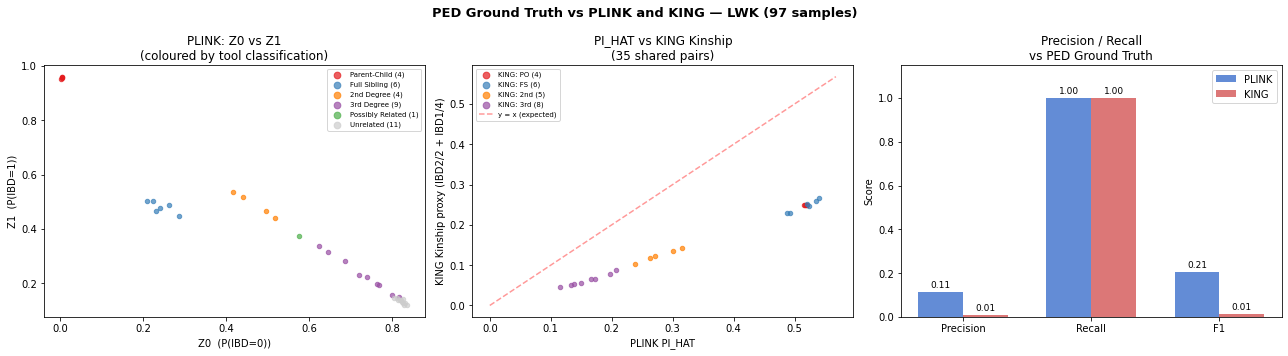

  Exported validation table → /home/r3james/cse284-relative-finding/results/ped_validation_table_lwk.csv

✓ Done.


In [17]:

# ─────────────────────────────────────────────────────────────
# 6. PLOTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("6. GENERATING PLOTS")
print("=" * 60)

# Always produce tool-vs-tool IBD distribution plots,
# even if PED ground truth is empty.
n_cols = 3 if len(gt_df) > 0 else 2
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5))
fig.suptitle("PED Ground Truth vs PLINK and KING — LWK (97 samples)",
             fontsize=13, fontweight="bold")

# ── Plot A: PLINK Z0 vs Z1 (all pairs), colour by Rel_PLINK ──
ax = axes[0]
rel_colors = {
    "Parent-Child":       "#e41a1c",
    "Full Sibling":       "#377eb8",
    "2nd Degree":         "#ff7f00",
    "3rd Degree":         "#984ea3",
    "1st Degree (other)": "#a65628",
    "Possibly Related":   "#4daf4a",
    "Unrelated":          "#cccccc",
}
for rel, color in rel_colors.items():
    mask = plink_df["Rel_PLINK"] == rel
    if mask.sum() == 0:
        continue
    ax.scatter(plink_df.loc[mask, "Z0"], plink_df.loc[mask, "Z1"],
               alpha=0.7, s=20, c=[color],
               label=f"{rel} ({mask.sum()})")
ax.set_xlabel("Z0  (P(IBD=0))")
ax.set_ylabel("Z1  (P(IBD=1))")
ax.set_title("PLINK: Z0 vs Z1\n(coloured by tool classification)")
ax.legend(fontsize=7, markerscale=1.5)

# ── Plot B: PLINK PI_HAT vs KING Kinship_proxy ───────────────
ax = axes[1]
both_pairs_df = pd.merge(
    plink_df[["pair","PI_HAT","Rel_PLINK"]],
    king_df[["pair","Kinship_proxy","Rel_KING","InfType"]],
    on="pair"
)
if len(both_pairs_df) > 0:
    inf_type_colors = {"PO":"#e41a1c","FS":"#377eb8","2nd":"#ff7f00",
                       "3rd":"#984ea3","UN":"#aaaaaa"}
    for inf_type, color in inf_type_colors.items():
        sub = both_pairs_df[both_pairs_df["InfType"] == inf_type]
        if len(sub) == 0:
            continue
        ax.scatter(sub["PI_HAT"], sub["Kinship_proxy"],
                   alpha=0.7, s=20, c=[color],
                   label=f"KING: {inf_type} ({len(sub)})")
    lim = max(both_pairs_df["PI_HAT"].max(),
              both_pairs_df["Kinship_proxy"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", alpha=0.4, label="y = x (expected)")
    ax.set_xlabel("PLINK PI_HAT")
    ax.set_ylabel("KING Kinship proxy (IBD2/2 + IBD1/4)")
    ax.set_title(f"PI_HAT vs KING Kinship\n({len(both_pairs_df)} shared pairs)")
    ax.legend(fontsize=7, markerscale=1.5)
else:
    ax.text(0.5, 0.5, "No overlapping pairs", ha="center", va="center",
            transform=ax.transAxes)
    ax.set_title("PI_HAT vs KING Kinship")

# ── Plot C (only if PED ground truth exists): Precision / Recall ─
if len(gt_df) > 0 and pr_results:
    ax = axes[2]
    metrics = ["Precision", "Recall", "F1"]
    x = np.arange(len(metrics))
    w = 0.35
    b1 = ax.bar(x - w/2, [pr_results[0][m] for m in metrics], w,
                label="PLINK", color="#4878CF", alpha=0.85)
    b2 = ax.bar(x + w/2, [pr_results[1][m] for m in metrics], w,
                label="KING",  color="#D65F5F", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title("Precision / Recall\nvs PED Ground Truth")
    ax.legend()
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f"{h:.2f}", ha="center", fontsize=9)

plt.tight_layout()
out_path = os.path.join("figures", "ped_validation_lwk.png")
plt.savefig(out_path, dpi=130, bbox_inches="tight")
print(f"  Saved → {out_path}")
plt.show()

# Export merged table
if len(gt_df) > 0:
    out_csv = os.path.join(OUT_DIR, "ped_validation_table_lwk.csv")
    merged_gt.to_csv(out_csv, index=False)
    print(f"  Exported validation table → {out_csv}")

print("\n✓ Done.")